# Monopoly Property Landing Probability
Starter notebook for estimating long-run landing probability on each board square.

In [5]:
using Pkg
Pkg.activate("..")

  Activating project at `c:\Users\RemiLequette\Development\julia\Monopoly`


In [7]:
include("../src/MonopolyProbability.jl")
include("../src/MonopolyVisualization.jl")

board = MonopolyProbability.standard_board()

# Graphical board rendering with Plots.jl
function show()
    p = MonopolyVisualization.plot_board_heatmap(probabilities; labels=board, label_chars=12)
    display(p)
end

show (generic function with 1 method)

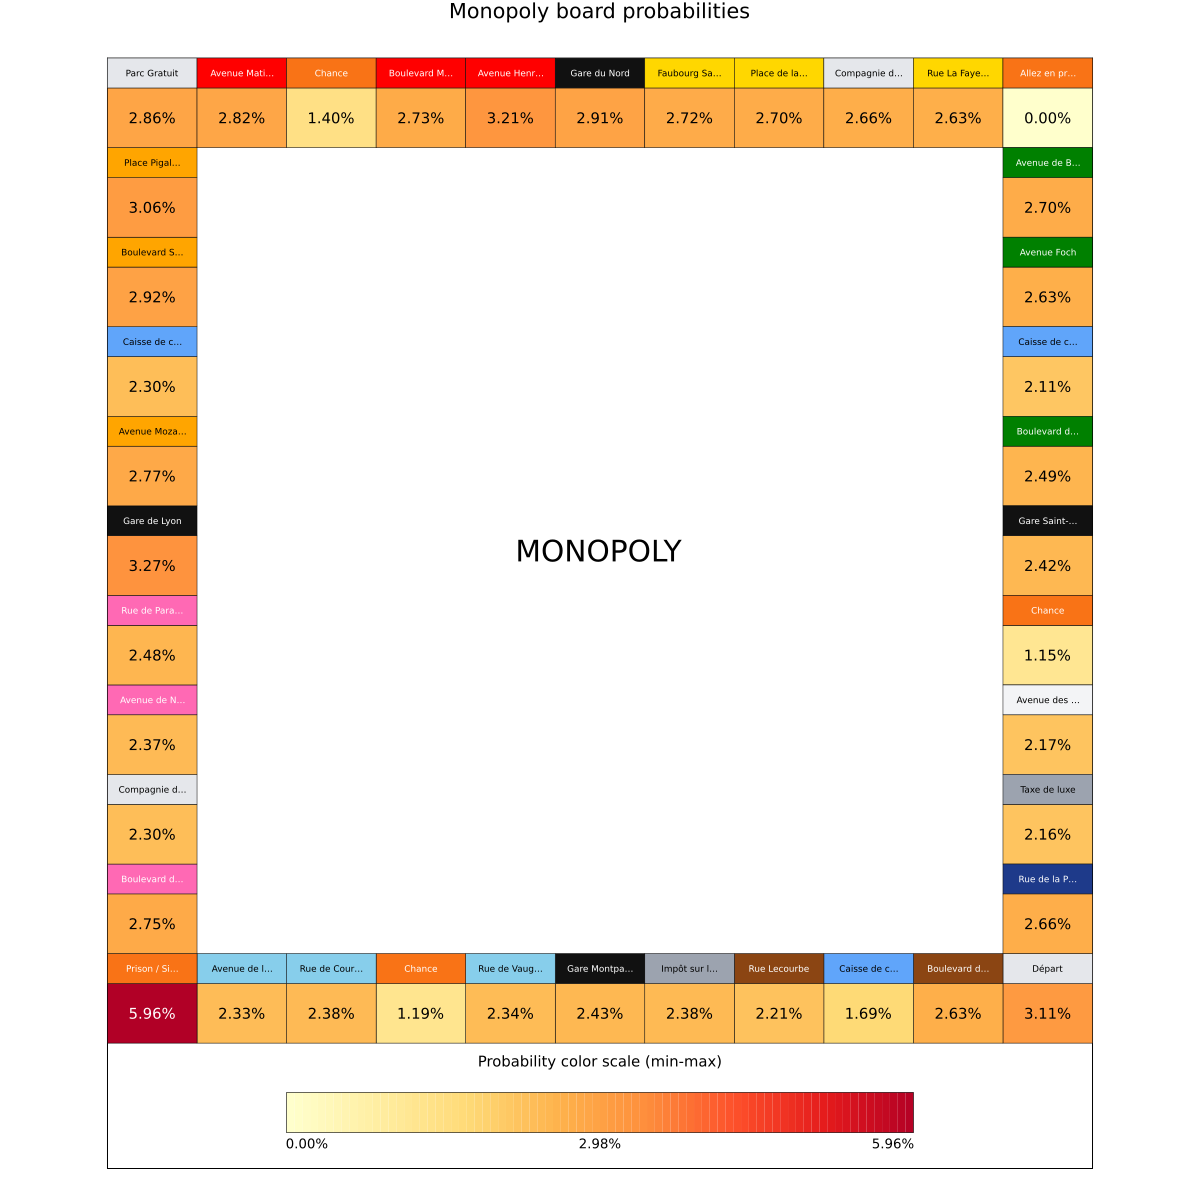

In [8]:
probabilities = MonopolyProbability.initial_probability_distribution()

probabilities = MonopolyProbability.simulate_n_throws(probabilities, 5000)

show()


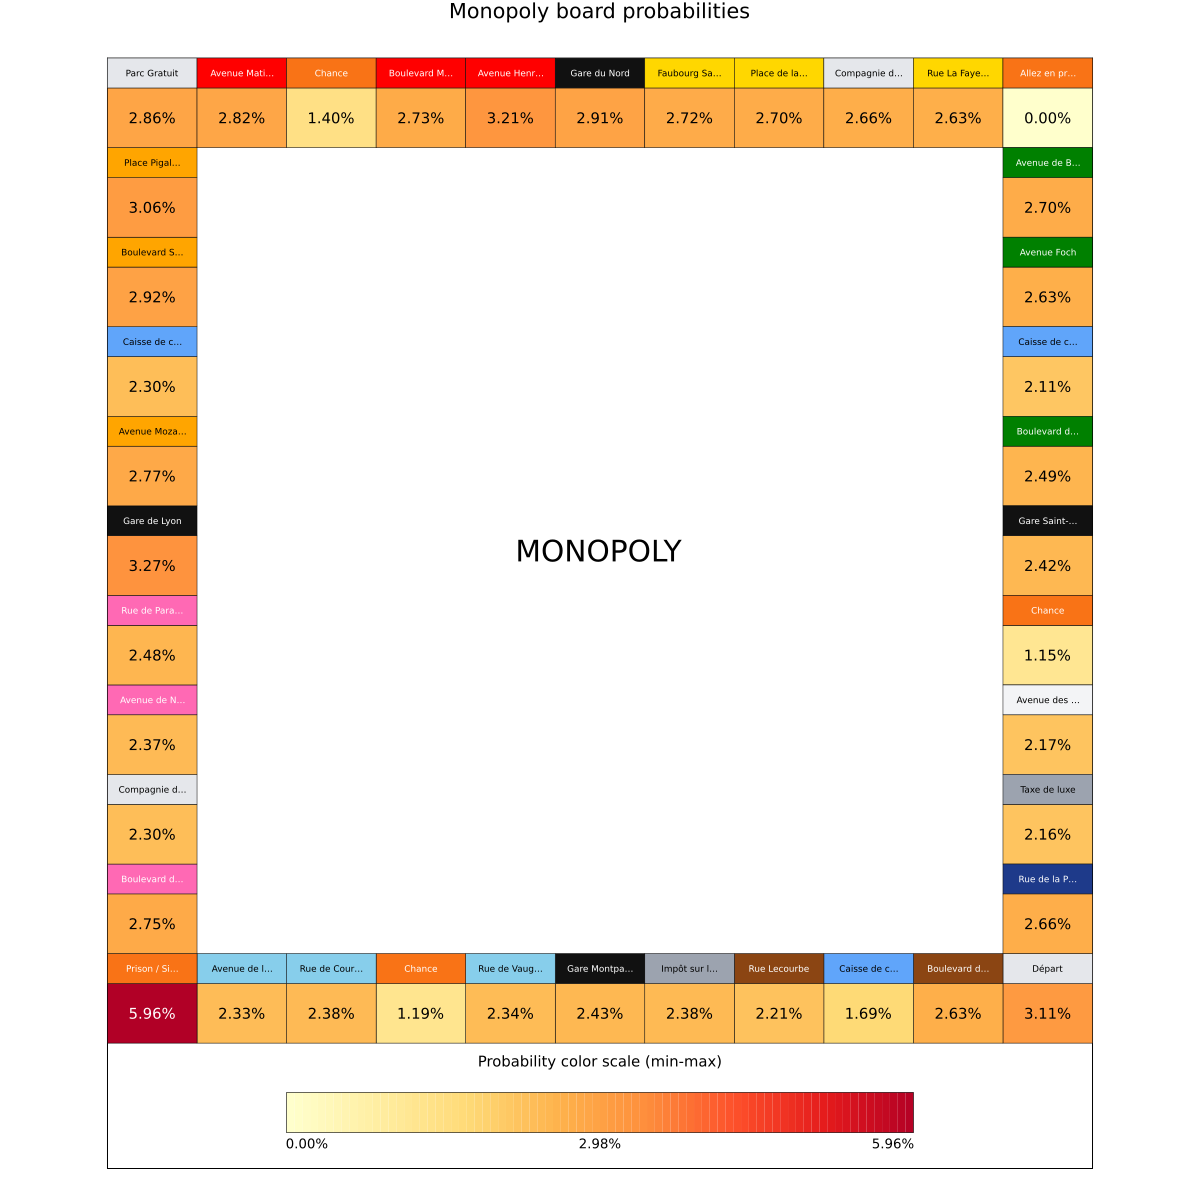

Converged: true after 156 iterations
11 - Prison / Simple visite         : 5.9581%
16 - Gare de Lyon                   : 3.2716%
25 - Avenue Henri-Martin            : 3.2104%
 1 - Départ                         : 3.1142%
20 - Place Pigalle                  : 3.0572%
19 - Boulevard Saint-Michel         : 2.9226%
26 - Gare du Nord                   : 2.9079%
21 - Parc Gratuit                   : 2.8604%
22 - Avenue Matignon                : 2.8243%
17 - Avenue Mozart                  : 2.7724%


In [10]:
# Long-run convergent probabilities (stationary distribution)
transition = MonopolyProbability.dice_transition_matrix()
stationary_probabilities, iterations, converged = MonopolyProbability.convergent_probabilities(transition)
println("Converged: ", converged, " after ", iterations, " iterations")

# Optional: reuse plotting helper from previous cells
probabilities = stationary_probabilities
show()

# Top-10 most visited squares
top_idx = sortperm(stationary_probabilities, rev=true)[1:10]
for idx in top_idx
    println(lpad(idx, 2), " - ", rpad(board[idx], 30), " : ", round(100 * stationary_probabilities[idx], digits=4), "%")
end